# Exploration notebook

Working notes from building the analysis: data checks, starting-XI and formation exploration, and intermediate tables.
The final, cleaned-up analysis is in [inter_2015_16_pass_network.ipynb](inter_2015_16_pass_network.ipynb).

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path

from statsbomb_tools.data import load_competitions, load_matches, get_team_id, team_matches, load_events
from statsbomb_tools.lineups import (
    player_appearances, formation_at_each_event, event_durations,
    minutes_by_formation, minutes_by_position, main_player_by_position,
)
from statsbomb_tools.passes import open_play_passes, receiver_positions, load_xT_grid, pass_xT
from statsbomb_tools.network import build_nodes, build_edges
from statsbomb_tools.plotting import use_space_mono, plot_formations

In [3]:
# Gather available Serie A data 
comps = load_competitions()
comps[comps["competition_name"].str.contains("Serie A", case=False)]

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
70,12,27,Italy,Serie A,male,False,False,2015/2016,2025-08-15T14:28:50.169562,NaN,NaN,2025-08-15T14:28:50.169562
71,12,86,Italy,Serie A,male,False,False,1986/1987,2025-11-23T11:00:00.442491,NaN,NaN,2025-11-23T11:00:00.442491
72,131,281,Italy,Serie A Women,female,False,False,2023/2024,2026-04-11T13:29:49.465639,NaN,NaN,2026-04-11T13:29:49.465639


In [4]:
# Set variables for relevant competition, season, and team name
COMPETITION_ID = 12
SEASON_ID = 27
TEAM_NAME = "Inter Milan"

# Collect all matches
matches = load_matches(COMPETITION_ID, SEASON_ID)
matches.head()

,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,...,home_manager_country_name,away_manager_id,away_manager_name,away_manager_nickname,away_manager_dob,away_manager_country_id,away_manager_country_name,data_version,shot_fidelity_version,xy_fidelity_version
0,3879608,2015-11-07,17:00:00.000,0,2,available,unscheduled,2025-08-15T14:12:51.209333,None,12,...,Italy,136,Roberto Donadoni,NaN,1963-09-09,112,Italy,1.1.0,2,2
1,3879551,2015-09-27,13:00:00.000,1,2,available,unscheduled,2025-08-15T14:07:54.221225,None,6,...,Italy,436,Stefano Pioli,NaN,1965-10-20,112,Italy,1.1.0,2,2
2,3879575,2015-10-18,13:00:00.000,1,1,available,unscheduled,2025-08-15T14:11:13.695281,None,8,...,Italy,1000693,Stefano Colantuono,NaN,1962-10-23,112,Italy,1.1.0,2,2
3,3879542,2015-09-23,18:45:00.000,1,0,available,unscheduled,2025-08-15T14:10:03.727003,None,5,...,Italy,4071,Andrea Mandorlini,NaN,1960-07-17,112,Italy,1.1.0,2,2
4,3879600,2015-11-01,14:00:00.000,0,0,available,unscheduled,2025-08-15T14:28:50.169562,None,11,...,Italy,4071,Andrea Mandorlini,NaN,1960-07-17,112,Italy,1.1.0,2,2


In [5]:
# Collect all matches for given team (home & away) + sanity check
TEAM_ID = get_team_id(matches, TEAM_NAME)
team_all_matches = team_matches(matches, TEAM_ID)

n_teams = pd.concat([matches["home_team_id"], matches["away_team_id"]]).nunique()
expected = 2 * (n_teams - 1)
assert len(team_all_matches) == expected, f"Expected {expected} matches, got {len(team_all_matches)}"

team_all_matches[["match_id", "match_date", "home_team", "home_team_id", "away_team", "away_team_id",
       "home_score", "away_score"]].head(10)

,match_id,match_date,home_team,home_team_id,away_team,away_team_id,home_score,away_score
0,3878543,2015-08-23,Inter Milan,238,Atalanta,228,1,0
1,3878552,2015-08-30,Carpi,1683,Inter Milan,238,1,2
2,3878600,2015-09-13,Inter Milan,238,AC Milan,243,1,0
3,3878611,2015-09-20,Chievo,231,Inter Milan,238,0,1
4,3879542,2015-09-23,Inter Milan,238,Hellas Verona,226,1,0
5,3879550,2015-09-27,Inter Milan,238,Fiorentina,239,1,4
6,3879565,2015-10-04,Sampdoria,234,Inter Milan,238,1,1
7,3879574,2015-10-18,Inter Milan,238,Juventus,224,0,0
8,3879579,2015-10-24,Palermo,2256,Inter Milan,238,1,1
9,3879587,2015-10-27,Bologna,240,Inter Milan,238,0,1


### Load event data from matches played by given team

In [6]:
# Load team games and their events; cached as .pkl per match to avoid re-downloading
DATA_DIR = Path("../data/events")
events = load_events(team_all_matches["match_id"], DATA_DIR)
print(f"{len(events):,} events from {events['match_id'].nunique()} matches")

38/38 matches loaded
138,481 events from 38 matches


In [7]:
# Sanity checks

# 1. Every match has a plausible number of events (typically 3,000-4,000)
display(events.groupby("match_id").size().describe())

# 2. team_id in the events matches the one from the matches table
team_ids = events.loc[events["team"] == TEAM_NAME, "team_id"].unique()
assert list(team_ids) == [TEAM_ID]

# 3. What event types do we have?
events["type"].value_counts().head(15)

count      38.000000
mean     3644.236842
std       244.506280
min      3176.000000
25%      3455.750000
50%      3650.000000
75%      3785.000000
max      4453.000000
dtype: float64

type
Pass              38034
Ball Receipt*     36699
Carry             29099
Pressure          13764
Ball Recovery      4044
Duel               2837
Clearance          1766
Block              1669
Dribble            1295
Goal Keeper        1170
Foul Committed     1156
Miscontrol         1100
Foul Won           1099
Shot               1006
Dispossessed        885
Name: count, dtype: int64

### Extract pass-related events 

In [8]:
open_play = open_play_passes(events, TEAM_ID)
print(f"{len(open_play):,} open-play {TEAM_NAME} passes")
open_play.head()

18,508 open-play Inter Milan passes


,id,match_id,minute,second,period,possession,player,player_id,passer_position,pass_recipient,pass_recipient_id,pass_type,pass_outcome,pass_length,x,y,end_x,end_y,completed
47,455d57b2-4a73-40b4-b02d-df9e31049510,3878543,0,53,1,3,Assane Demoya Gnoukouri,40348.0,Center Defensive Midfield,João Miranda de Souza Filho,5551.0,NaN,NaN,22.217110,28.0,15.0,19.2,35.4,True
50,872e700d-0298-4852-9dc1-7e28e17722a7,3878543,1,0,1,3,João Miranda de Souza Filho,5551.0,Right Center Back,Assane Demoya Gnoukouri,40348.0,NaN,NaN,24.120737,33.5,57.0,34.5,32.9,True
53,0958e4cb-e62b-4b20-b5af-cb1a6531d884,3878543,1,3,1,3,Assane Demoya Gnoukouri,40348.0,Center Defensive Midfield,Juan Guilherme Nunes Jesus,6969.0,NaN,NaN,30.709770,36.8,32.9,41.8,2.6,True
56,054fd052-5224-4966-93c9-6734c3ed23f6,3878543,1,6,1,3,Juan Guilherme Nunes Jesus,6969.0,Left Back,Samir Handanovič,7001.0,NaN,NaN,43.481490,41.5,2.1,15.7,37.1,True
58,d7dd09d6-8cf9-4d14-90ea-5c81caa8c932,3878543,1,10,1,3,Samir Handanovič,7001.0,Goalkeeper,João Miranda de Souza Filho,5551.0,NaN,NaN,19.564508,15.7,37.1,27.1,53.0,True


### Explore team Starting 11's and Formations throughout the season
As seen below, in the case of 2015-2016 Inter Milan, many starting 11/formations combinations were used during the season.


In [9]:
appearances = player_appearances(events, TEAM_ID)

In [10]:
squad = (
    appearances.groupby("player_id")
    .agg(player=("player", "first"),
         minutes=("minutes", "sum"),
         matches=("match_id", "nunique"))
    .join(appearances[appearances["on"] == 0].groupby("player_id")["position"]
          .agg(lambda s: s.mode().iloc[0]).rename("position"))
    .sort_values("minutes", ascending=False)
    .reset_index()
)
display(squad.head(15))

,player_id,player,minutes,matches,position
0,7001,Samir Handanovič,3377.0,36,Goalkeeper
1,6585,Jeison Fabián Murillo Cerón,2954.0,34,Left Center Back
2,5551,João Miranda de Souza Filho,2857.0,32,Right Center Back
3,6987,Mauro Emanuel Icardi Rivero,2656.0,33,Center Forward
4,5474,Ivan Perišić,2511.0,34,Left Wing
5,16453,Gary Alexis Medel Soto,2502.0,30,Center Defensive Midfield
6,5469,Marcelo Brozović,2492.0,32,Right Center Midfield
7,6589,Geoffrey Kondogbia,2056.0,26,Left Center Midfield
8,25430,Felipe Melo de Carvalho,1840.0,26,Center Defensive Midfield
9,5690,Yuto Nagatomo,1717.0,22,Left Back


In [11]:
# Our formation at every event, and how long each event lasts, then minutes per formation
events["formation"] = formation_at_each_event(events, TEAM_ID)
events["duration"] = event_durations(events)
formation_minutes = minutes_by_formation(events)

# Sanity check: 38 matches, each ~90 min plus stoppage time
display(events.groupby("match_id")["duration"].sum().describe())

open_play["formation"] = events["formation"]
display(formation_minutes)

count    38.000000
mean     95.356493
std       1.694755
min      92.945383
25%      94.067100
50%      95.303150
75%      96.750183
max      99.347917
Name: duration, dtype: float64

,minutes,matches
formation,,
4-2-3-1,977.0,17
4-4-2,770.0,13
4-3-3,546.0,13
4-1-2-1-2,467.0,9
3-5-2,296.0,10
4-4-1-1,249.0,9
4-1-4-1,142.0,3
3-4-1-2,73.0,4
4-3-2-1,65.0,1


In [12]:
# Only plot formations used for at least this many minutes
MIN_MINUTES = 700

formations = formation_minutes[formation_minutes["minutes"] >= MIN_MINUTES].index.tolist()
network_passes = open_play[open_play["formation"].isin(formations)].copy()

network_passes.groupby("formation").agg(
    passes=("completed", "size"),
    completed=("completed", "sum"),
)

,passes,completed
formation,,
4-2-3-1,5294,4271
4-4-2,4179,3397


In [13]:
network_passes["receiver_position"] = receiver_positions(network_passes, events, TEAM_ID)

completed = network_passes[network_passes["completed"]]
print(f"{completed['receiver_position'].isna().sum()} of {len(completed):,} completed passes have no receiver position")

# Preview: completed passes between positions in the first formation
first = completed[completed["formation"] == formations[0]]
pd.crosstab(first["passer_position"], first["receiver_position"])

4 of 7,668 completed passes have no receiver position


receiver_position,Center Attacking Midfield,Center Forward,Goalkeeper,Left Back,Left Center Back,Left Defensive Midfield,Left Wing,Right Back,Right Center Back,Right Defensive Midfield,Right Wing
passer_position,,,,,,,,,,,
Center Attacking Midfield,0,44,1,32,8,56,70,47,13,54,61
Center Forward,34,0,0,12,6,16,19,14,3,19,29
Goalkeeper,12,1,0,15,27,11,12,10,27,10,4
Left Back,63,17,8,0,39,88,140,4,4,40,24
Left Center Back,25,8,29,124,0,85,23,12,77,49,8
Left Defensive Midfield,67,30,6,101,69,0,76,51,50,107,55
Left Wing,83,23,4,66,20,75,0,15,7,47,26
Right Back,39,33,8,2,12,35,13,0,86,64,98
Right Center Back,16,13,26,28,87,43,15,111,0,62,43


In [14]:
position_minutes = minutes_by_position(events, TEAM_ID)

# Sanity check: each position should be filled for ~all of the formation's minutes
position_minutes.groupby(["formation", "position"])["minutes"].sum().loc[formations].round()

formation  position                 
4-2-3-1    Center Attacking Midfield    977.0
           Center Forward               977.0
           Goalkeeper                   977.0
           Left Back                    977.0
           Left Center Back             977.0
           Left Defensive Midfield      977.0
           Left Wing                    977.0
           Right Back                   977.0
           Right Center Back            976.0
           Right Defensive Midfield     977.0
           Right Wing                   977.0
4-4-2      Goalkeeper                   770.0
           Left Back                    770.0
           Left Center Back             767.0
           Left Center Forward          770.0
           Left Defensive Midfield      770.0
           Left Midfield                770.0
           Right Back                   769.0
           Right Center Back            770.0
           Right Center Forward         770.0
           Right Defensive Midfield     770

In [15]:
top_players = main_player_by_position(position_minutes, formation_minutes)

# Crosstab with the passer's top player added to each row label
labels = top_players[top_players["formation"] == formations[0]].set_index("position")["player"]
table = pd.crosstab(first["passer_position"], first["receiver_position"])
table.rename(index=lambda pos: f"{pos} ({labels[pos]})")

receiver_position,Center Attacking Midfield,Center Forward,Goalkeeper,Left Back,Left Center Back,Left Defensive Midfield,Left Wing,Right Back,Right Center Back,Right Defensive Midfield,Right Wing
passer_position,,,,,,,,,,,
Center Attacking Midfield (Stevan Jovetić),0,44,1,32,8,56,70,47,13,54,61
Center Forward (Mauro Emanuel Icardi Rivero),34,0,0,12,6,16,19,14,3,19,29
Goalkeeper (Samir Handanovič),12,1,0,15,27,11,12,10,27,10,4
Left Back (Yuto Nagatomo),63,17,8,0,39,88,140,4,4,40,24
Left Center Back (Jeison Fabián Murillo Cerón),25,8,29,124,0,85,23,12,77,49,8
Left Defensive Midfield (Geoffrey Kondogbia),67,30,6,101,69,0,76,51,50,107,55
Left Wing (Ivan Perišić),83,23,4,66,20,75,0,15,7,47,26
Right Back (Danilo D''Ambrosio),39,33,8,2,12,35,13,0,86,64,98
Right Center Back (João Miranda de Souza Filho),16,13,26,28,87,43,15,111,0,62,43


In [16]:
# Threat added by each pass (0 for incomplete and backward passes)
xT_grid = load_xT_grid(Path("../data/xT_grid.json"))
network_passes["xT"] = pass_xT(network_passes, xT_grid)

In [17]:
nodes = build_nodes(network_passes, formation_minutes, top_players)
nodes[["formation", "position", "player", "share", "completed_p90", "completion", "xT_p90", "x", "y"]].round(2)

,formation,position,player,share,completed_p90,completion,xT_p90,x,y
0,4-2-3-1,Center Attacking Midfield,Stevan Jovetić,0.37,35.56,0.76,0.18,76.88,38.11
1,4-2-3-1,Center Forward,Mauro Emanuel Icardi Rivero,0.80,14.00,0.72,0.08,77.40,42.41
2,4-2-3-1,Goalkeeper,Samir Handanovič,0.90,11.88,0.80,0.01,10.79,39.43
3,4-2-3-1,Left Back,Yuto Nagatomo,0.51,39.33,0.77,0.21,61.74,11.54
4,4-2-3-1,Left Center Back,Jeison Fabián Murillo Cerón,0.67,40.53,0.88,0.06,40.42,25.95
5,4-2-3-1,Left Defensive Midfield,Geoffrey Kondogbia,0.53,56.38,0.87,0.12,59.26,30.58
6,4-2-3-1,Left Wing,Ivan Perišić,0.81,33.72,0.73,0.15,76.21,16.47
7,4-2-3-1,Right Back,Danilo D''Ambrosio,0.56,35.93,0.76,0.17,60.01,69.16
8,4-2-3-1,Right Center Back,João Miranda de Souza Filho,0.89,40.90,0.82,0.08,42.08,54.63
9,4-2-3-1,Right Defensive Midfield,Gary Alexis Medel Soto,0.57,53.43,0.88,0.11,56.82,43.73


In [18]:
edges = build_edges(network_passes, nodes, formation_minutes)
display(edges.groupby("formation")["completed_p90"].describe().round(1))
edges.nlargest(10, "xT_per_pass")[["formation", "pos_a", "pos_b", "completed_p90", "xT_per_pass"]].round(3)

,count,mean,std,min,25%,50%,75%,max
formation,,,,,,,,
4-2-3-1,55.0,7.2,5.6,0.1,2.4,5.3,11.1,19.5
4-4-2,55.0,7.2,5.2,0.2,2.1,6.5,11.5,20.0


,formation,pos_a,pos_b,completed_p90,xT_per_pass
33,4-2-3-1,Center Forward,Left Wing,3.869,0.022
34,4-2-3-1,Left Back,Right Wing,3.869,0.020
81,4-4-2,Left Midfield,Right Midfield,6.662,0.019
83,4-4-2,Right Center Forward,Right Midfield,6.545,0.016
39,4-2-3-1,Center Forward,Left Back,2.671,0.016
92,4-4-2,Left Back,Right Center Back,3.390,0.016
52,4-2-3-1,Left Back,Right Back,0.553,0.015
24,4-2-3-1,Center Attacking Midfield,Center Forward,7.185,0.015
82,4-4-2,Left Defensive Midfield,Right Center Forward,6.545,0.014
27,4-2-3-1,Center Forward,Right Wing,5.343,0.014


In [19]:
# Short names for labels; anyone not listed keeps their StatsBomb name
DISPLAY_NAMES = {
    "Samir Handanovič": "Handanovič",
    "Danilo D''Ambrosio": "D'Ambrosio",
    "João Miranda de Souza Filho": "Miranda",
    "Jeison Fabián Murillo Cerón": "Murillo",
    "Yuto Nagatomo": "Nagatomo",
    "Alex Nicolao Telles": "Alex Telles",
    "Gary Alexis Medel Soto": "Medel",
    "Geoffrey Kondogbia": "Kondogbia",
    "Felipe Melo de Carvalho": "Felipe Melo",
    "Jonathan Ludovic Biabiany": "Biabiany",
    "Stevan Jovetić": "Jovetić",
    "Ivan Perišić": "Perišić",
    "Mauro Emanuel Icardi Rivero": "Icardi",
}

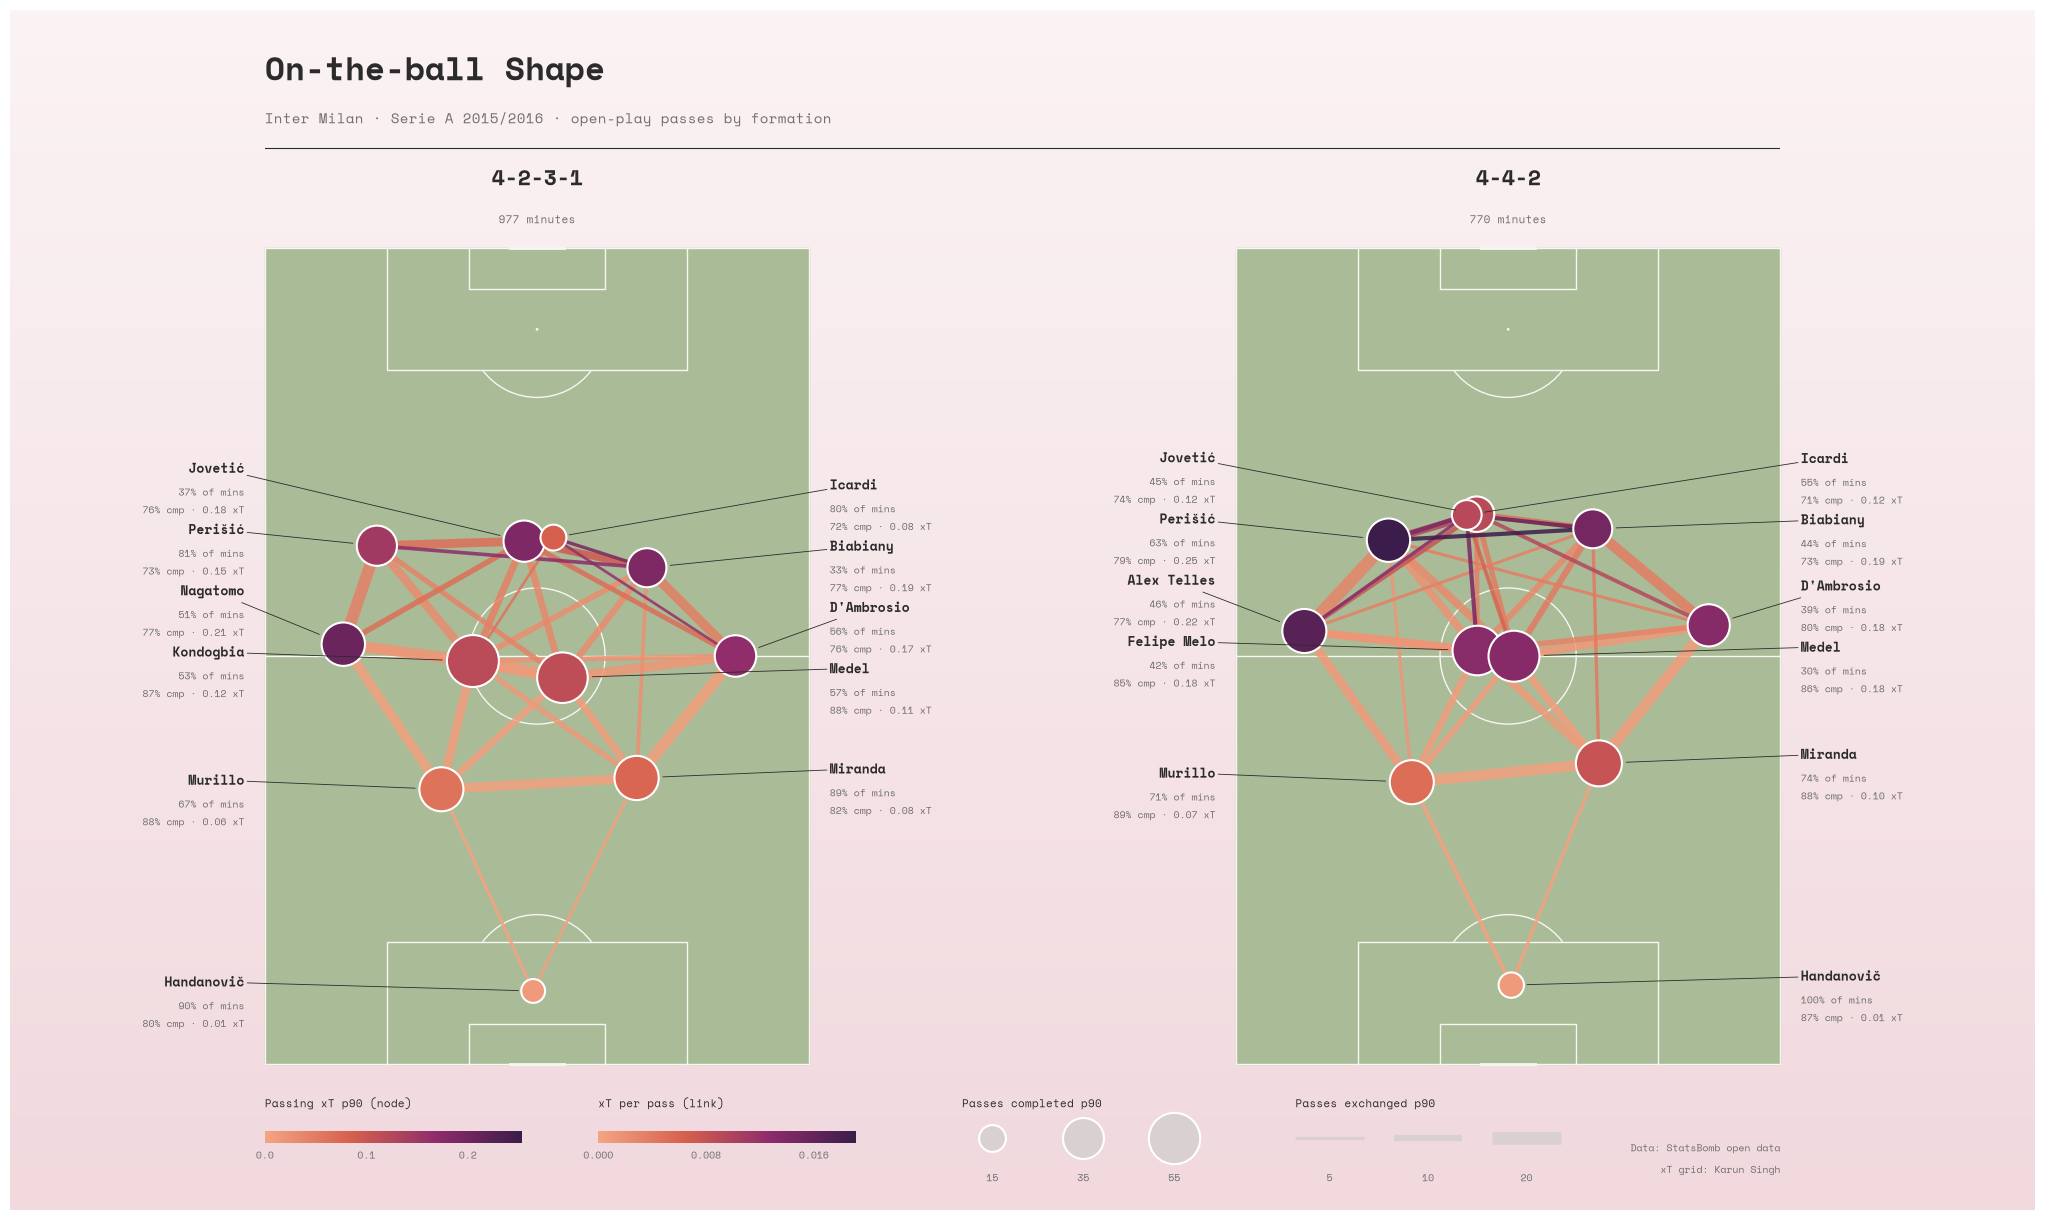

In [20]:
use_space_mono(Path("../data/fonts"))

season = comps[(comps["competition_id"] == COMPETITION_ID) & (comps["season_id"] == SEASON_ID)].iloc[0]
fig = plot_formations(
    nodes, edges, formation_minutes, formations,
    title="On-the-ball Shape",
    subtitle=f"{TEAM_NAME} · {season['competition_name']} {season['season_name']} · open-play passes by formation",
    display_names=DISPLAY_NAMES,
)

In [21]:
# Save the figure for the README / sharing
OUTPUT_DIR = Path("../output")
OUTPUT_DIR.mkdir(exist_ok=True)

filename = f"{TEAM_NAME}_{season['season_name']}_pass_networks.png".replace(" ", "_").replace("/", "-")
fig.savefig(OUTPUT_DIR / filename, dpi=200)
print(f"Saved to {OUTPUT_DIR / filename}")

Saved to ../output/Inter_Milan_2015-2016_pass_networks.png
